# Nemotron 3 Nano 30B A3B: 8K input, 128K output, disaggregated versus aggregated

The reverse of the 128K-input study: **8,000 prompt tokens and exactly 131,072 forced output
tokens** (`ignore_eos`) per request, at the highest concurrency the KV pool allows.
Both modes use the same 16 H200 GPUs as four TP4 workers:

- **Aggregated:** four TP4 replicas, 512 requests in flight (128 per worker).
- **Disaggregated:** one TP4 prefill worker and three TP4 decode workers, 384 in flight (128 per decode worker).

Each run is one closed-loop wave: all requests start together and the run ends when the last
finishes. All worker caches are cleared before each run; prompts are unique.
ITL comes from client stream-event intervals (coverage shows the fraction of tokens that
arrived in their own event) and, independently, from SGLang's server-side histogram.
Run all cells with the repository `.venv` kernel. No load is generated here.

In [1]:
from pathlib import Path
import os, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / 'benchmarks').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from benchmarks.collect import collect
RESULTS = Path(os.environ.get('NEMOTRON_8K_128K_RESULTS', ROOT / 'results/nemotron-3-nano-8k-128k-comparison'))
EXPORT = RESULTS / 'analysis'
EXPORT.mkdir(parents=True, exist_ok=True)
summary_path = collect(RESULTS) if RESULTS.exists() else None
runs = pd.read_csv(summary_path) if summary_path else pd.DataFrame()
LABELS = {'dynamo-disagg-k8s': 'Disaggregated (1P + 3D, TP4)', 'dynamo-agg-k8s': 'Aggregated (4 x TP4)'}
ORDER = list(LABELS.values())
COLORS = dict(zip(ORDER, ['#217c91', '#d47c36']))
plt.style.use('seaborn-v0_8-whitegrid')
if not runs.empty:
    runs['mode'] = runs.technology.map(LABELS)
print(f'{len(runs)} runs from {RESULTS}')

6 runs -> <repo>/results/nemotron-3-nano-8k-128k-comparison/summary.csv
6 runs from <repo>/results/nemotron-3-nano-8k-128k-comparison


/var/folders/1x/4dvr_l6n0vb4khb5qd3s00kh0000gn/T/ipykernel_2466/2181896355.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runs['mode'] = runs.technology.map(LABELS)


## Audit the experiment

Failures, invalid measurements (any completion that is not exactly 131,072 tokens) and
mismatched settings must be visible before speed. Concurrency differs by design: each mode
runs at 128 requests per decode-capable worker.

In [2]:
requests = pd.DataFrame()
if not runs.empty:
    display(runs[['run_id','mode','requests','failed_requests','invalid_measurements','duration_s',
                  'concurrency','prompt_tokens_mean','completion_tokens_mean','completion_tokens_max',
                  'itl_token_coverage','server_histograms_complete']])
    for field in ['dataset_sha256','model','model_revision','image','gpu_count','max_model_len',
                  'requested_output_tokens','min_input_tokens','extra_body_json','temperature','cache_state']:
        assert runs[field].nunique(dropna=False) == 1, f'Mismatched setting: {field}'
    assert (runs.failed_requests == 0).all() and (runs.invalid_measurements == 0).all()
    # Runs before the round-robin frontend used the KV router; the balance table below checks placement.
    runs['router'] = [json.loads((RESULTS / r / 'metadata.json').read_text())['deployment'].get(
        'frontend_router_mode', 'kv (30-frontend.yaml)') for r in runs.run_id]
    display(runs[['run_id', 'mode', 'router']])
    frames = []
    for row in runs.itertuples():
        frame = pd.read_csv(RESULTS / row.run_id / 'requests.csv')
        frame['mode'] = row.mode
        frames.append(frame)
    requests = pd.concat(frames, ignore_index=True)
    # Same prompt for the same session in every run of a mode, and across modes where shared.
    hashes = requests.groupby('session_id').request_sha256.nunique()
    assert (hashes == 1).all(), 'Request bodies differ between runs'
    balance = requests.groupby(['mode','run_id','decode_worker_id']).size().groupby(['mode','run_id']).agg(['min','max'])
    display(balance.rename(columns={'min':'fewest requests on a decode worker','max':'most requests on a decode worker'}))

,run_id,mode,requests,failed_requests,invalid_measurements,duration_s,concurrency,prompt_tokens_mean,completion_tokens_mean,completion_tokens_max,itl_token_coverage,server_histograms_complete
0,20261001T140242Z-8fafdc7b,Aggregated (4 x TP4),512,0,0,1943.784112,512,8000,131072,131072,0.999891,True
1,20261001T143536Z-e3b85d7d,Aggregated (4 x TP4),512,0,0,1934.495306,512,8000,131072,131072,0.999963,True
2,20261001T160754Z-da1a442e,Aggregated (4 x TP4),512,0,0,1927.497108,512,8000,131072,131072,0.999859,True
3,20261001T165156Z-d6a807a3,"Disaggregated (1P + 3D, TP4)",384,0,0,1942.546101,384,8000,131072,131072,0.999918,True
4,20261001T172431Z-9bde84bd,"Disaggregated (1P + 3D, TP4)",384,0,0,1956.511772,384,8000,131072,131072,0.999803,True
5,20261001T175720Z-09b15755,"Disaggregated (1P + 3D, TP4)",384,0,0,1941.746699,384,8000,131072,131072,0.999864,True


/var/folders/1x/4dvr_l6n0vb4khb5qd3s00kh0000gn/T/ipykernel_2466/436981028.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runs['router'] = [json.loads((RESULTS / r / 'metadata.json').read_text())['deployment'].get(


,run_id,mode,router
0,20261001T140242Z-8fafdc7b,Aggregated (4 x TP4),kv (30-frontend.yaml)
1,20261001T143536Z-e3b85d7d,Aggregated (4 x TP4),kv (30-frontend.yaml)
2,20261001T160754Z-da1a442e,Aggregated (4 x TP4),round-robin (31-frontend-round-robin.yaml)
3,20261001T165156Z-d6a807a3,"Disaggregated (1P + 3D, TP4)",round-robin (31-frontend-round-robin.yaml)
4,20261001T172431Z-9bde84bd,"Disaggregated (1P + 3D, TP4)",round-robin (31-frontend-round-robin.yaml)
5,20261001T175720Z-09b15755,"Disaggregated (1P + 3D, TP4)",round-robin (31-frontend-round-robin.yaml)


fewest requests on a decode worker  \
mode                         run_id                                                          
Aggregated (4 x TP4)         20261001T140242Z-8fafdc7b                                 128   
                             20261001T143536Z-e3b85d7d                                 128   
                             20261001T160754Z-da1a442e                                 128   
Disaggregated (1P + 3D, TP4) 20261001T165156Z-d6a807a3                                 128   
                             20261001T172431Z-9bde84bd                                 128   
                             20261001T175720Z-09b15755                                 128   

                                                        most requests on a decode worker  
mode                         run_id                                                       
Aggregated (4 x TP4)         20261001T140242Z-8fafdc7b                               128  
                             20261001T143536Z-e3b85d7d                               128  
                             20261001T160754Z-da1a442e                               128  
Disaggregated (1P + 3D, TP4) 20261001T165156Z-d6a807a3                               128  
                             20261001T172431Z-9bde84bd                               128  
                             20261001T175720Z-09b15755                               128

## Throughput

`output_throughput_tps` is valid output tokens divided by wall time, including the prefill ramp
and the tail. `steady_decode_tps` counts only the window in which every stream has its first
token and none has finished.

,mode,concurrency,duration_min,output_throughput_tps,output_tps_per_gpu,steady_decode_tps,total_output_tokens
0,Aggregated (4 x TP4),512,32.396402,34524.854680,2157.803417,35231.996408,67108864
1,Aggregated (4 x TP4),512,32.241588,34690.631600,2168.164475,35325.029077,67108864
2,Aggregated (4 x TP4),512,32.124952,34816.583498,2176.036469,35305.509203,67108864
3,"Disaggregated (1P + 3D, TP4)",384,32.375768,25910.143379,1619.383961,27177.582643,50331648
4,"Disaggregated (1P + 3D, TP4)",384,32.608530,25725.195582,1607.824724,27196.506864,50331648
5,"Disaggregated (1P + 3D, TP4)",384,32.362445,25920.810379,1620.050649,27180.419178,50331648


duration_min                        \
                                     mean        min        max   
mode                                                              
Disaggregated (1P + 3D, TP4)    32.448914  32.362445  32.608530   
Aggregated (4 x TP4)            32.254314  32.124952  32.396402   

                             output_throughput_tps                \
                                              mean           min   
mode                                                               
Disaggregated (1P + 3D, TP4)          25852.049780  25725.195582   
Aggregated (4 x TP4)                  34677.356593  34524.854680   

                                           output_tps_per_gpu               \
                                       max               mean          min   
mode                                                                         
Disaggregated (1P + 3D, TP4)  25920.810379        1615.753111  1607.824724   
Aggregated (4 x TP4)          34816.583498        2167.334787  2157.803417   

                                          steady_decode_tps                \
                                      max              mean           min   
mode                                                                        
Disaggregated (1P + 3D, TP4)  1620.050649      27184.836229  27177.582643   
Aggregated (4 x TP4)          2176.036469      35287.511563  35231.996408   

                                            
                                       max  
mode                                        
Disaggregated (1P + 3D, TP4)  27196.506864  
Aggregated (4 x TP4)          35325.029077

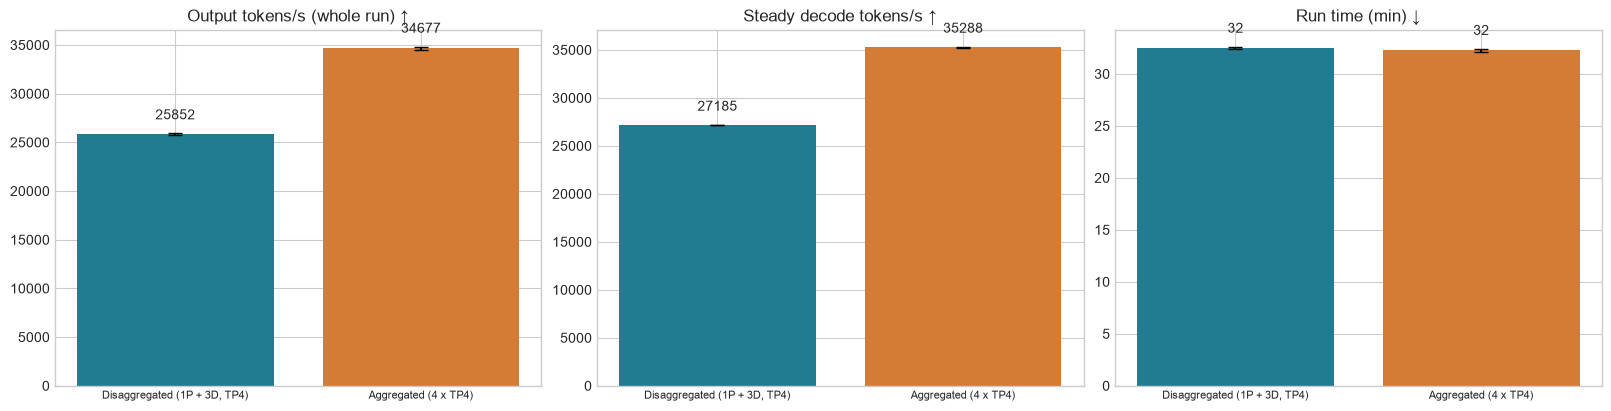

In [3]:
comparison = pd.DataFrame()
if not runs.empty:
    comparison = runs.copy()
    comparison['output_tps_per_gpu'] = comparison.output_throughput_tps / comparison.gpu_count
    comparison['duration_min'] = comparison.duration_s / 60
    cols = ['mode','concurrency','duration_min','output_throughput_tps','output_tps_per_gpu','steady_decode_tps',
            'total_output_tokens']
    display(comparison[cols])
    comparison.to_csv(EXPORT / 'topology-comparison.csv', index=False)
    metrics = ['duration_min','output_throughput_tps','output_tps_per_gpu','steady_decode_tps']
    aggregate = comparison.groupby('mode')[metrics].agg(['mean','min','max']).reindex([m for m in ORDER if m in set(comparison['mode'])])
    display(aggregate); aggregate.to_csv(EXPORT / 'throughput-aggregate.csv')
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), layout='constrained')
    for ax, col, title in zip(axes, ['output_throughput_tps','steady_decode_tps','duration_min'],
                              ['Output tokens/s (whole run) ↑','Steady decode tokens/s ↑','Run time (min) ↓']):
        stat = aggregate[col]
        bars = ax.bar(stat.index, stat['mean'], yerr=np.vstack([stat['mean']-stat['min'], stat['max']-stat['mean']]),
                      capsize=5, color=[COLORS[m] for m in stat.index])
        ax.bar_label(bars, fmt='%.0f', padding=8); ax.set_title(title); ax.tick_params(axis='x', labelsize=8)
    fig.savefig(EXPORT / 'throughput.png', dpi=180, bbox_inches='tight'); plt.show()

## TTFT, TPOT and ITL

TTFT is dominated by prefill queueing: every request arrives at once, so the last prompt in a
worker's queue waits for all earlier ones. TPOT is per-request mean decode time per token.
ITL percentiles pool every token interval of every valid request in the run (about 67M samples
aggregated, 50M disaggregated). Server ITL is the SGLang histogram delta across the run, summed over workers.

mode,"Disaggregated (1P + 3D, TP4)",Aggregated (4 x TP4)
ttft_ms_p50,36532.339,10993.837
ttft_ms_p99,72631.898,22604.278
ttft_ms_max,73213.331,23016.273
tpot_ms_p50,14.147,14.512
tpot_ms_p99,14.349,14.752
itl_ms_p50,13.126,13.168
itl_ms_p90,18.555,18.705
itl_ms_p99,20.703,20.949
itl_ms_p99_9,499.108,509.648
itl_ms_max,1141.410,40438.191


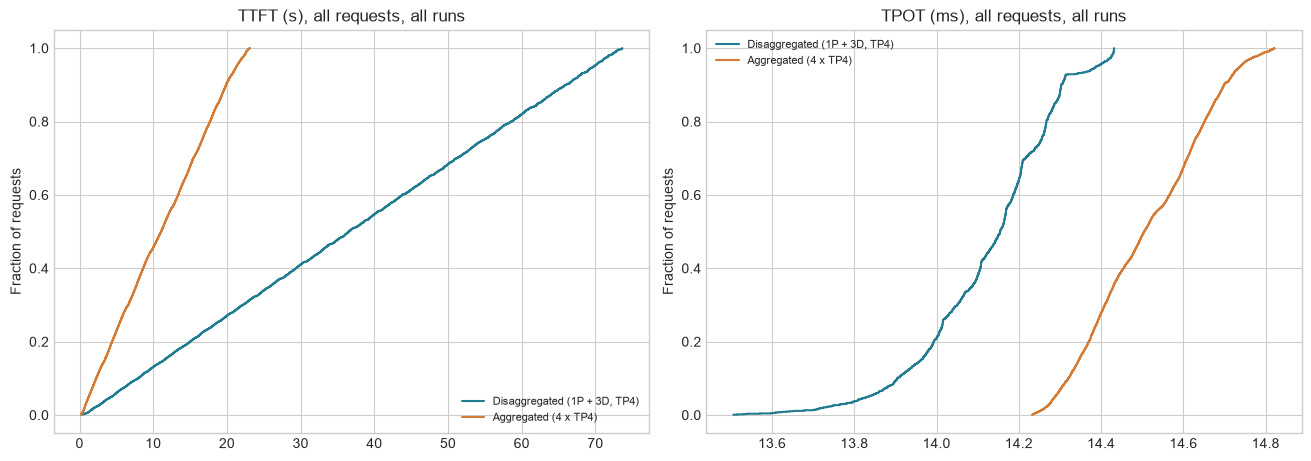

In [4]:
if not runs.empty:
    lat = ['ttft_ms_p50','ttft_ms_p99','ttft_ms_max','tpot_ms_p50','tpot_ms_p99','itl_ms_p50','itl_ms_p90',
           'itl_ms_p99','itl_ms_p99_9','itl_ms_max','server_itl_ms_p50','server_itl_ms_p99','itl_token_coverage']
    latency = comparison.groupby('mode')[lat].mean().reindex([m for m in ORDER if m in set(comparison['mode'])]).T
    display(latency.round(3)); latency.to_csv(EXPORT / 'latency-means.csv')
    good = requests[requests.measurement_valid == True].copy()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')
    for mode in ORDER:
        part = good[good['mode'] == mode]
        for ax, col, scale in [(axes[0], 'ttft_ms', 1000), (axes[1], 'tpot_ms', 1)]:
            v = np.sort(part[col].dropna() / scale)
            if len(v): ax.step(v, np.arange(1, len(v)+1)/len(v), where='post', label=mode, color=COLORS[mode])
    axes[0].set_title('TTFT (s), all requests, all runs'); axes[1].set_title('TPOT (ms), all requests, all runs')
    for ax in axes: ax.set_ylabel('Fraction of requests'); ax.legend(fontsize=8)
    fig.savefig(EXPORT / 'ttft-tpot-cdf.png', dpi=180, bbox_inches='tight'); plt.show()

## ITL as the output grows

Each output-position bin (1,024 tokens) pools that position across all requests in a run;
the line is the mean over runs. Attention cost grows with context, so ITL rises with
position. In aggregated mode, the start also contains prefill chunks that stall decode.

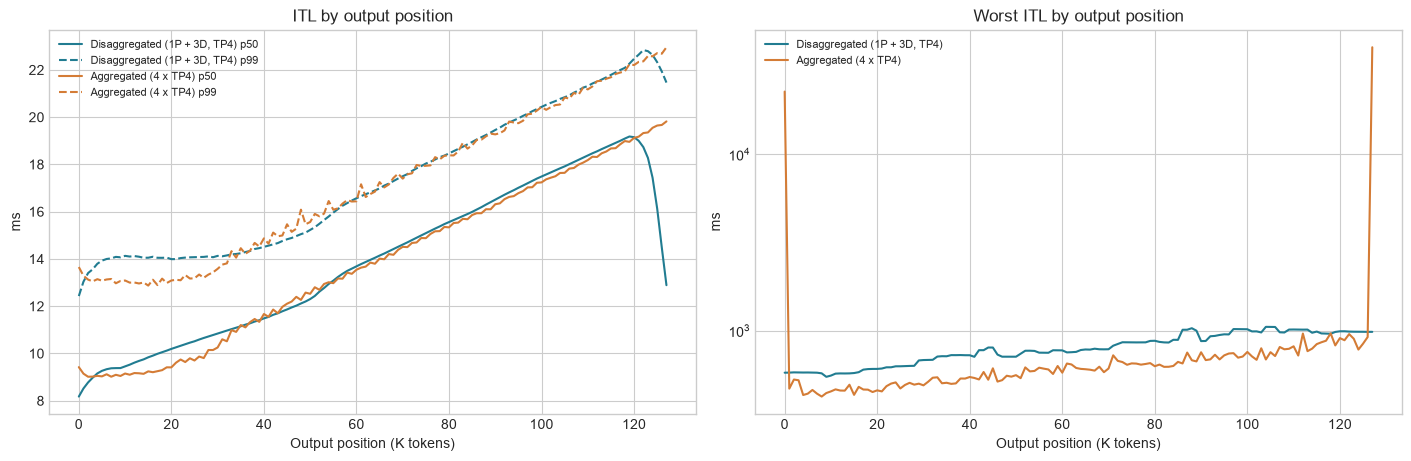

In [5]:
if not runs.empty:
    tables = []
    for row in runs.itertuples():
        t = pd.read_csv(RESULTS / row.run_id / 'itl_by_position.csv'); t['mode'] = row.mode; tables.append(t)
    position = pd.concat(tables).groupby(['mode','output_token_start'])[['itl_ms_p50','itl_ms_p99','itl_ms_max']].mean().reset_index()
    position.to_csv(EXPORT / 'itl-by-position.csv', index=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), layout='constrained')
    for mode in ORDER:
        p = position[position['mode'] == mode]
        axes[0].plot(p.output_token_start/1024, p.itl_ms_p50, label=mode+' p50', color=COLORS[mode])
        axes[0].plot(p.output_token_start/1024, p.itl_ms_p99, '--', label=mode+' p99', color=COLORS[mode])
        axes[1].plot(p.output_token_start/1024, p.itl_ms_max, label=mode, color=COLORS[mode])
    axes[0].set_title('ITL by output position'); axes[1].set_title('Worst ITL by output position')
    axes[1].set_yscale('log')
    for ax in axes: ax.set_xlabel('Output position (K tokens)'); ax.set_ylabel('ms'); ax.legend(fontsize=8)
    fig.savefig(EXPORT / 'itl-by-position.png', dpi=180, bbox_inches='tight'); plt.show()

## Cluster output rate over time

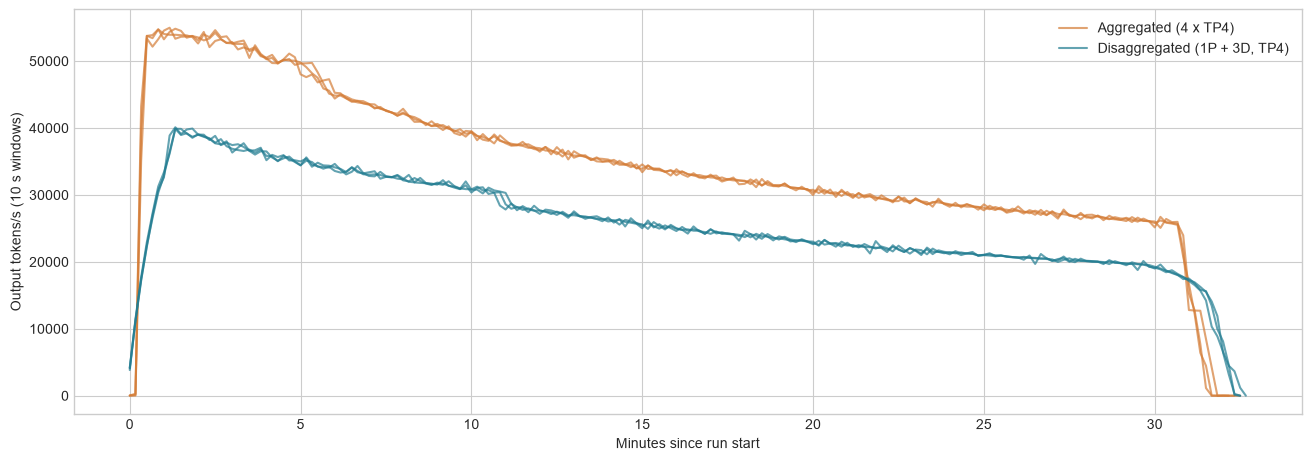

In [6]:
if not runs.empty:
    fig, ax = plt.subplots(figsize=(13, 4.5), layout='constrained')
    for row in runs.itertuples():
        t = pd.read_csv(RESULTS / row.run_id / 'throughput_timeline.csv')
        ax.plot(t.window_start_s/60, t.events_per_s, color=COLORS[row.mode], alpha=.7,
                label=row.mode if row.run_id == runs[runs['mode']==row.mode].run_id.iloc[0] else None)
    ax.set_xlabel('Minutes since run start'); ax.set_ylabel('Output tokens/s (10 s windows)'); ax.legend()
    fig.savefig(EXPORT / 'throughput-timeline.png', dpi=180, bbox_inches='tight'); plt.show()

## Concurrency pilots

Short pilots (8,192 forced output tokens) used to choose concurrency. Their contexts stay
below 16K, so absolute TPOT/ITL is lower than in the full 128K runs.

In [7]:
pilot_root = RESULTS / 'pilots'
if pilot_root.exists() and any(pilot_root.glob('*/summary.json')):
    pilots = pd.DataFrame([json.loads(p.read_text()) for p in sorted(pilot_root.glob('*/summary.json'))])
    pilots = pilots[pilots.label == 'pilot']
    pilots['mode'] = pilots.technology.map(LABELS)
    cols = ['mode','concurrency','requested_output_tokens','output_throughput_tps','steady_decode_tps',
            'ttft_ms_p50','ttft_ms_max','tpot_ms_p50','itl_ms_p50','itl_ms_p99','server_itl_ms_p50','server_itl_ms_p99']
    pilots = pilots[cols].sort_values(['mode','concurrency'])
    display(pilots.round(2)); pilots.to_csv(EXPORT / 'pilot-sweep.csv', index=False)

,mode,concurrency,requested_output_tokens,output_throughput_tps,steady_decode_tps,ttft_ms_p50,ttft_ms_max,tpot_ms_p50,itl_ms_p50,itl_ms_p99,server_itl_ms_p50,server_itl_ms_p99
1,Aggregated (4 x TP4),64,8192,12639.57,13340.67,1374.17,3055.95,4.81,4.51,5.58,4.52,5.80
2,Aggregated (4 x TP4),128,8192,20527.45,22061.62,2682.97,5468.69,5.82,5.31,7.01,5.51,6.83
3,Aggregated (4 x TP4),256,8192,31473.16,35100.35,5509.18,11179.85,7.31,6.33,8.78,6.46,8.47
4,Aggregated (4 x TP4),512,8192,31034.48,NaN,11564.05,105186.71,11.04,8.97,12.68,8.99,11.46
8,"Disaggregated (1P + 3D, TP4)",48,8192,8551.31,10331.86,4341.58,8819.54,4.66,4.60,5.88,4.56,5.94
9,"Disaggregated (1P + 3D, TP4)",96,8192,13164.31,17854.17,8683.55,17514.47,5.42,5.33,7.14,5.52,6.94
10,"Disaggregated (1P + 3D, TP4)",192,8192,18514.83,29365.91,17736.31,35870.31,6.63,6.49,8.99,6.51,8.30
11,"Disaggregated (1P + 3D, TP4)",384,8192,23905.56,NaN,36158.41,73825.89,8.58,8.11,12.36,8.11,11.66


## Side by side with the 128K-input study

The two studies differ in TP size (TP8 versus TP4), concurrency, context and output budget,
so this table places the workloads side by side; it is not a controlled comparison of one variable.

In [8]:
LONG = ROOT / 'results/nemotron-3-nano-128k-comparison/summary.csv'
if LONG.exists() and not runs.empty:
    long = pd.read_csv(LONG); long['study'] = '128K in / 256 out (TP8, c=4)'
    long['mode'] = long.technology.map({'dynamo-disagg-k8s':'Disaggregated','dynamo-agg-k8s':'Aggregated'})
    short = runs.copy(); short['study'] = '8K in / 128K out (TP4, max c)'
    short['mode'] = short.technology.map({'dynamo-disagg-k8s':'Disaggregated','dynamo-agg-k8s':'Aggregated'})
    cols = ['output_throughput_tps','input_throughput_tps','ttft_ms_p50','tpot_ms_p50','duration_s']
    both = pd.concat([long, short]).groupby(['study','mode'])[cols].mean()
    display(both.round(2)); both.to_csv(EXPORT / 'cross-study.csv')

output_throughput_tps  \
study                         mode                                   
128K in / 256 out (TP8, c=4)  Aggregated                    262.56   
                              Disaggregated                 161.19   
8K in / 128K out (TP4, max c) Aggregated                  34677.36   
                              Disaggregated               25852.05   

                                             input_throughput_tps  \
study                         mode                                  
128K in / 256 out (TP8, c=4)  Aggregated                189072.13   
                              Disaggregated             116539.48   
8K in / 128K out (TP4, max c) Aggregated                  2116.54   
                              Disaggregated               1577.88   

                                             ttft_ms_p50  tpot_ms_p50  \
study                         mode                                      
128K in / 256 out (TP8, c=4)  Aggregated          110.28         4.35   
                              Disaggregated      2502.66         4.64   
8K in / 128K out (TP4, max c) Aggregated        10993.84        14.51   
                              Disaggregated     36532.34        14.15   

                                             duration_s  
study                         mode                       
128K in / 256 out (TP8, c=4)  Aggregated          65.09  
                              Disaggregated      105.48  
8K in / 128K out (TP4, max c) Aggregated        1935.26  
                              Disaggregated     1946.93

## Interpretation and limits

- Both modes allocate 16 GPUs, but disaggregation dedicates one quarter of them to an 8K
  prefill that is under 0.1% of the work, so it has three decode workers to aggregated's four.
- Each run is a single synchronized wave. That maximizes the prefill burst at the start and
  makes the tail end abruptly; steady arrival rates would spread prefills through decode.
- Outputs are forced with `ignore_eos` and not quality-scored; after an end-of-sequence token
  the text is not meaningful, but the compute per token is the same.
- Overlap scheduling is disabled in both modes (as in the 128K study), BF16 weights, native KV dtype.
- Three runs per mode show only limited variation. Topology order is fixed (aggregated first).